# Machine Learning 

### Informacion del dataset

- Información Intentos de Suicidio Municipio de Tunja, Boyacá
- Fuente: https://www.datos.gov.co/Salud-y-Protecci-n-Social/Informaci-n-Intentos-de-Suicidio-Municipio-de-Tunj/nk8x-s9hw/about_data
- API: https://www.datos.gov.co/api/v3/views/nk8x-s9hw/query.json




| Campo                    | Información               |
| ------------------------ | ------------------------- |
| **Departamento**         | Boyacá                    |
| **Municipio**            | Tunja                     |
| **DIVIPOLA Municipio**   | 15001                     |
| **Nombre de la Entidad** | Alcaldía de Tunja, Boyacá |
| **Orden**                | Territorial               |
| **Sector**               | Planeación                |

# Información de Datos

| Campo                           | Información |
| ------------------------------- | ----------- |
| **Cobertura Geográfica**        | Municipal   |
| **Idioma**                      | Español     |
| **Frecuencia de Actualización** | Trimestral  |

# Temas

| Campo         | Información                                                          |
| ------------- | -------------------------------------------------------------------- |
| **Categoría** | Salud y Protección Social                                            |
| **Etiquetas** | intento de suicidio, mpal de tunja, tunja, salud y protección social |

# Licencia y atribución

| Campo                   | Información                                                  |
| ----------------------- | ------------------------------------------------------------ |
| **Licencia**            | Creative Commons Attribution | Share Alike 4.0 International |
| **Enlace de la fuente** | https://www.datos.gov.co/d/nk8x-s9hw                         |


#### Cargue de librerias

In [18]:
import pandas as pd
import numpy as np


# Tratamiento de datos
# ==============================================================================
import unicodedata
import re


# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

### Cargar dataset


In [19]:
# Cargar dataset
df = pd.read_csv('data/data.csv', sep=',', encoding='utf-8', dtype={'ID_ANO': str})

df.head()

,ID_ANO,FECHA_DE_ NOTIFICACION_ DEL_ EVENTO,EDAD_DE_LA_VICTIMA,UNIDAD_DE_MEDIDA_DE _LA_VICTIMA,SEXO,AREA_ DE_ RESIDENCIA,BARRIO_ DE_ RESIDENCIA,SEGURIDAD_ SOCIAL,ESTRATO_SOCIOECONOMICO,GESTANTE,...,ARMA_ CORTOPUNZANTE,ARMA _DE_ FUEGO,INMOLACION,LANZAMIENTO_ AL_ VACIO,LANZAMIENTO_ A_ VEHICULO,LANZAMIENTO_ AL_ AGUA,INTOXICACIONES,REMITIDO_ A_ PSIQUIATRIA,REMITIDO_ A_ PSICOLOGIA,REMITIDO_ A_ TRABAJO_ SOCIAL
0,2.020,2020 Jan 02 12:00:00 AM,27,AÑOS,FEMENINO,CABECERA MUNICIPAL,CASTILLA,CONTRIBUTIVO,3,NO,...,SI,NO,NO,NO,NO,FALSO,NO,SI,SI,NO
1,2.020,2020 Jan 03 12:00:00 AM,45,AÑOS,FEMENINO,CABECERA MUNICIPAL,LA MARIA,CONTRIBUTIVO,5,NO,...,NO,NO,NO,NO,NO,FALSO,SI,SI,SI,NO
2,2.020,2020 Jan 17 12:00:00 AM,51,AÑOS,MASCULINO,CABECERA MUNICIPAL,EL LIBERTADOR,NO ASEGURADO,2,NO APLICA,...,NO,NO,NO,SI,NO,FALSO,NO,SI,SI,NO
3,2.020,2020 Jan 21 12:00:00 AM,23,AÑOS,MASCULINO,CABECERA MUNICIPAL,ASIS BOYACENSE,CONTRIBUTIVO,3,NO APLICA,...,SI,NO,NO,NO,NO,FALSO,SI,SI,SI,NO
4,2.020,2020 Jan 21 12:00:00 AM,27,AÑOS,MASCULINO,CABECERA MUNICIPAL,REMANSOS DE LA SABANA,CONTRIBUTIVO,3,NO APLICA,...,SI,NO,NO,NO,NO,FALSO,NO,SI,NO,NO


### Ver la descripcion general del dataset

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 48 columns):
 #   Column                                            Non-Null Count  Dtype
---  ------                                            --------------  -----
 0   ID_ANO                                            818 non-null    str  
 1   FECHA_DE_ NOTIFICACION_ DEL_ EVENTO               818 non-null    str  
 2   EDAD_DE_LA_VICTIMA                                818 non-null    int64
 3   UNIDAD_DE_MEDIDA_DE _LA_VICTIMA                   818 non-null    str  
 4   SEXO                                              818 non-null    str  
 5   AREA_ DE_ RESIDENCIA                              818 non-null    str  
 6   BARRIO_ DE_ RESIDENCIA                            818 non-null    str  
 7   SEGURIDAD_ SOCIAL                                 818 non-null    str  
 8   ESTRATO_SOCIOECONOMICO                            818 non-null    int64
 9   GESTANTE                                          818 

A simple vista observamos algunos datos nulos en los indices del 31 al 34 los cuales revisaremos a continuación con mas detalle para determinar si es posible normalizarlos.

A si mismo teniendo en cuenta que en su gran mayoria las variables estudiadas estan typadas como string y corresponde a variables dicotomicas será necesario relizar un proceso de mapeo para su respectiva normalización. 

In [21]:

df.describe()

,EDAD_DE_LA_VICTIMA,ESTRATO_SOCIOECONOMICO
count,818.000000,818.000000
mean,23.986553,2.533007
std,10.560593,0.964237
min,6.000000,1.000000
25%,17.000000,2.000000
50%,21.000000,3.000000
75%,27.000000,3.000000
max,80.000000,5.000000


En este momento solo contamos con 2 variables numericas como los son la edad que cuenta con una distribución de 6 a 80 con una mediana de 21 años, lo que muestra que la población estudiada es bastante joven.


### Revisar la calidad de los datos

In [22]:
for columna in df.columns:
    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")
    print(df[columna].unique())


Variable: ID_ANO
<StringArray>
['2.020', '2.021', '2.022', '2.023', '2.024']
Length: 5, dtype: str

Variable: FECHA_DE_ NOTIFICACION_ DEL_ EVENTO
<StringArray>
['2020 Jan 02 12:00:00 AM', '2020 Jan 03 12:00:00 AM',
 '2020 Jan 17 12:00:00 AM', '2020 Jan 21 12:00:00 AM',
 '2020 Jan 23 12:00:00 AM', '2020 Jan 24 12:00:00 AM',
 '2020 Feb 03 12:00:00 AM', '2020 Feb 04 12:00:00 AM',
 '2020 Feb 09 12:00:00 AM', '2020 Feb 13 12:00:00 AM',
 ...
 '2024 Mar 13 12:00:00 AM', '2024 Mar 15 12:00:00 AM',
 '2024 Mar 16 12:00:00 AM', '2024 Mar 20 12:00:00 AM',
 '2024 Mar 23 12:00:00 AM', '2024 Mar 24 12:00:00 AM',
 '2024 Mar 25 12:00:00 AM', '2024 Mar 26 12:00:00 AM',
 '2024 Mar 27 12:00:00 AM', '2024 Mar 28 12:00:00 AM']
Length: 576, dtype: str

Variable: EDAD_DE_LA_VICTIMA
[27 45 51 23 55 34 43 22 17 18 19 25 26 37 21 14 16 33 40 20 57 12 13 50
 15 29 30 31 24 38 62 48 41 39 52  7 36 35 80 56 28 32 11 74 49 68 10 44
 47  9 54 61  8 69 46 42  6 63]

Variable: UNIDAD_DE_MEDIDA_DE _LA_VICTIMA
<StringAr

Al revisar los datos registrados en cada una de las variables, identificamos que en las siguientes variables es necesario  validar la calidad de los datos, y realizar unificacion de los registros realizados con problemas de escritura,
- AREA_ DE_ RESIDENCIA
- BARRIO_ DE_ RESIDENCIA
- SEGURIDAD_ SOCIAL
- INTENTOS_ PREVIOS
- NUMERO_ DE_ INTENTOS
- ESTADO_CIVIL
- ESCOLARIDAD

Para normalizar estas variables teniendo en cuenta que corresponden a errores en el registro de la informacion crearemos un diccionario de normalización para unificar los valores registrados en cada variable.
 

##### Eliminamos la columna UNIDAD_DE_MEDIDA_DE _LA_VICTIMA
Esta variable no aporta valor al dataset, y por lo tanto se elimina de la misma.

In [23]:
df.drop(columns=['UNIDAD_DE_MEDIDA_DE _LA_VICTIMA'], inplace=True)

### Normalizamos nombres de las variables

In [24]:
#Normalizamos nombres de las variables

def limpiar_nombre_columna(col):

    # convertir a string
    col = str(col)

    # quitar tildes
    col = unicodedata.normalize('NFKD', col)\
        .encode('ascii', errors='ignore')\
        .decode('utf-8')

    # mayúsculas -> minúsculas
    col = col.lower()

    # eliminar espacios inicio/final
    col = col.strip()

    # reemplazar espacios y underscores múltiples
    col = re.sub(r'[\s_]+', '_', col)

    # quitar caracteres raros
    col = re.sub(r'[^a-z0-9_]', '', col)

    # quitar underscores al inicio/final
    col = col.strip('_')

    return col
df.columns = [limpiar_nombre_columna(c) for c in df.columns]

#### Creamos diccionario de normalización

In [25]:
# =========================================================
# FUNCION GENERAL DE NORMALIZACION
# =========================================================

def normalizar_dataset(df):

    # =====================================================
    # 1. NORMALIZAR TEXTO GLOBAL
    # =====================================================

    def limpiar_texto(texto):

        if pd.isna(texto):
            return np.nan

        texto = str(texto)

        # quitar espacios
        texto = texto.strip()

        # mayúsculas
        texto = texto.upper()

        # quitar tildes
        texto = unicodedata.normalize('NFKD', texto)\
            .encode('ascii', errors='ignore')\
            .decode('utf-8')

        return texto

    # aplicar a columnas object
    cols_texto = df.select_dtypes(include='object').columns

    for col in cols_texto:
        df[col] = df[col].apply(limpiar_texto)

    # =====================================================
    # 2. CONVERTIR STRINGS FALSOS A NaN
    # =====================================================

    df.replace(
        ['NAN', 'NULL', 'NONE' ],
        np.nan,
        inplace=True
    )


    # =====================================================
    # 3. DICCIONARIOS DE NORMALIZACION
    # =====================================================

    normalizaciones = {

        'area_de_residencia': {
            'RURALDISPERSO': 'RURAL DISPERSO',
            'CABECERA MUNICPAL': 'CABECERA MUNICIPAL'
        },

        'seguridad_social': {
            'CONTIRBUTIVO': 'CONTRIBUTIVO',
            'EXCEPCION': 'EXCEPTUADO',
            'EXCEPCIÓN': 'EXCEPTUADO',
            'EXCPCION': 'EXCEPTUADO',
            'INDETERMINADO': 'SIN INFORMACION'
        },

        'intentos_previos': {
            'SI': 'SI',
            '1': 'SI',
            'NO': 'NO',
            '2': 'SI'
        },

        'numero_de_intentos': {
            'NO APLICA': 0,
            '0': 0,
            '1': 1,
            '2': 2,
            '3': 3,
            '4': 4,
            'UNA VEZ': 1,
            'DOS VECES': 2,
            'TRES VECES': 3,
            'CUATRO VECES': 4,
            'MAS DE TRES VECES': 4
        },

        'estado_civil': {
            'SOLTERO': 'SOLTERO(A)',
            'SOLTERO/A': 'SOLTERO(A)',
            'SOLTERO (A)': 'SOLTERO(A)',
            'CASADO/A': 'CASADO(A)',
            'DIVORCIADO/A': 'DIVORCIADO(A)'
        },

        'escolaridad': {
            'BASICASECUNDARIA': 'BASICA SECUNDARIA',
            'PREESCOLAR': 'PRE ESCOLAR',
            'MEDIA TECN': 'MEDIA TECNICA',
            'TECNOLOGICA': 'TECNOLOGIA O TECNICA',
            'TECNOLOGICA O TECNICA': 'TECNOLOGIA O TECNICA',
            'TECNOLOGIA O TECNIA': 'TECNOLOGIA O TECNICA',
            'TECNICA O TECNOLOGICA': 'TECNOLOGIA O TECNICA'
        },

        'estado_civil':{
               'SOLTERO': 'SOLTERO(A)',
               'SOLTERO/A': 'SOLTERO(A)',
               'SOLTERO (A)': 'SOLTERO(A)',
               'CASADO/A': 'CASADO(A)',
               'DIVORCIADO/A': 'DIVORCIADO(A)'

        },

        'escolaridad':{
             'BASICASECUNDARIA': 'BASICA SECUNDARIA',
             'PREESCOLAR': 'PRE ESCOLAR',
             'MEDIA TECN': 'MEDIA TECNICA',
             'TECNOLOGICA': 'TECNOLOGIA O TECNICA',
             'TECNOLOGICA O TECNICA': 'TECNOLOGIA O TECNICA',
             'TECNOLOGIA O TECNIA': 'TECNOLOGIA O TECNICA',
             'TECNICA O TECNOLOGICA': 'TECNOLOGIA O TECNICA',
             'TECNICA PROFESIONAL': 'TECNOLOGIA O TECNICA',

        },

        'lanzamiento_al_agua': {
            'FALSO': 'NO'
        },

    }

    # =====================================================
    # 4. APLICAR NORMALIZACIONES
    # =====================================================

    for columna, mapa in normalizaciones.items():
        if columna in df.columns:
            df[columna] = df[columna].replace(mapa)

    # =====================================================
    # 5. CONVERTIR TIPOS
    # =====================================================

    columnas_numericas = [
        'numero_de_intentos'
    ]

    for col in columnas_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
            )

    # =====================================================
    # 6. CONVERTIR A CATEGORY
    # =====================================================

    columnas_categoria = [
        'intentos_previos',
        'area_de_residencia',
        'seguridad_social',
        'estado_civil',
        'escolaridad',
        'estado_civil',
        'escolaridad'
    ]

    for col in columnas_categoria:
        if col in df.columns:
            df[col] = df[col].astype('category')

    # =====================================================
    # 7. REPORTE FINAL
    # =====================================================

    print("\nDATASET NORMALIZADO\n")

    for col in normalizaciones.keys():

        if col in df.columns:

            print(f"\n{'='*60}")
            print(f"COLUMNA: {col}")
            print(f"{'='*60}")

            print(df[col].value_counts(dropna=False))

    return df

df = normalizar_dataset(df)


DATASET NORMALIZADO


COLUMNA: area_de_residencia
area_de_residencia
CABECERA MUNICIPAL    804
RURAL DISPERSO         14
Name: count, dtype: int64

COLUMNA: seguridad_social
seguridad_social
CONTRIBUTIVO       396
SUBSIDIADO         311
EXCEPTUADO          62
PARTICULAR          20
NO ASEGURADO        18
ESPECIAL             8
SIN INFORMACION      3
Name: count, dtype: int64

COLUMNA: intentos_previos
intentos_previos
SI    449
NO    369
Name: count, dtype: int64

COLUMNA: numero_de_intentos
numero_de_intentos
1    365
0    216
2    115
3     70
4     52
Name: count, dtype: int64

COLUMNA: estado_civil
estado_civil
SOLTERO(A)       648
UNION LIBRE      101
CASADO(A)         52
DIVORCIADO(A)     14
VIUDO(A)           3
Name: count, dtype: int64

COLUMNA: escolaridad
escolaridad
BASICA SECUNDARIA       392
BASICA PRIMARIA         132
PROFESIONAL             105
TECNOLOGIA O TECNICA     68
MEDIA TECNICA            65
SIN INFORMACION          32
NINGUNO                  10
ESPECIALIZACION

C:\Users\ansal\AppData\Local\Temp\ipykernel_19892\3005650719.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = df.select_dtypes(include='object').columns


#### Normalizamos barrio_de_residencia



Al revisar barrio_de_residencia identificamos que muchos registros corresponden al mismo barrio escrito de forma distinta por ello construimos un diccionario especifico que nos permita unificar los nombres de los barrios que presentan problemas de escritura.

In [26]:
# Diccionario de normalización para barrio_de_residencia

normalizacion_barrios = {

  'AMERICAS': 'LAS AMERICAS',
    'BOSQUE': 'EL BOSQUE',
    'CARMEN': 'EL CARMEN',
    'COJINES': 'LOS COJINES',
    'EL CONSUELO': 'CONSUELO',
    'CRISTALES': 'LOS CRISTALES',
    'DORADO': 'EL DORADO',
    'EL JORDAN': 'JORDAN',
    'EL LIBERTADOR': 'LIBERTADOR',
    'MILAGRO': 'EL MILAGRO',
    'REFUGIO': 'EL REFUGIO',
    'TOPO': 'EL TOPO',
    'ESMERALDA': 'LA ESMERALDA',
    'FLORIDA': 'LA FLORIDA',
    'FUENTE': 'LA FUENTE',
    'LANCEROS': 'LOS LANCEROS',
    'NIEVES': 'LAS NIEVES',
    'QUINTAS': 'LAS QUINTAS',
    'MUISCAS': 'LOS MUISCAS',
    'LOS PATRIOTAS': 'PATRIOTAS',
    'TRIGALES': 'LOS TRIGALES',
    'LO COJINES': 'LOS COJINES',
    'LANCERO': 'LOS LANCEROS',
    'MUICAS': 'LOS MUISCAS',
    'VEINTE DE ULIO': '20 DE JULIO',
    'VEINTE DE JULIO': '20 DE JULIO',
    '20 JULIO': '20 DE JULIO',
    'PINOS DE ORUIENTE': 'PINOS DE ORIENTE',
    'SANCARLOS': 'SAN CARLOS',
    'SANANTONIO': 'SAN ANTONIO',
    'LA FEUNTE': 'LA FUENTE',
    'SAN FRANSISCO': 'SAN FRANCISCO',
    'SAN FRACISCO': 'SAN FRANCISCO',
    'VIILADEL ROSARIO': 'VILLA DEL ROSARIO',
    'KENEDY': 'KENNEDY',
    'KENEDDY': 'KENNEDY',
    'REMANSON DE LA SABANA': 'REMANSOS DE LA SABANA',
    'REMANSO DE LA SABANA': 'REMANSOS DE LA SABANA',
    'MESOPOTAMINA': 'MESOPOTAMIA',
    'FUENTE HIGUERA': 'FUENTE HIGUERAS',
    'FUENTE HIGURAS': 'FUENTE HIGUERAS',
    'URASANDY': 'URAZANDY',
    'URAZANDI': 'URAZANDY',
    'TIRUNFO': 'EL TRIUNFO',
    'GAITAN': 'JORGE ELIECER GAITAN',
    'ASIS': 'ASIS BOYACENSE',
    'ESCANDINAVO': 'MIRADOR ESCANDINAVO',
    'V LA COLORADA': 'LA COLORADA',
}

barrios_antes = df['barrio_de_residencia'].nunique()
df['barrio_de_residencia'] = df['barrio_de_residencia'].replace(normalizacion_barrios)
barrios_despues = df['barrio_de_residencia'].nunique()

print(f"Barrios únicos antes de normalizar: {barrios_antes}")
print(f"Barrios únicos después de normalizar: {barrios_despues}")
print("\nTop 10 barrios luego de la normalización:")
print(df['barrio_de_residencia'].value_counts().head(10))

Barrios únicos antes de normalizar: 210
Barrios únicos después de normalizar: 162

Top 10 barrios luego de la normalización:
barrio_de_residencia
LOS MUISCAS       46
CENTRO            45
ANTONIA SANTOS    39
LAS NIEVES        22
LIBERTADOR        21
EL DORADO         21
ALTAMIRA          19
PATRIOTAS         18
SAN FRANCISCO     17
ASIS BOYACENSE    16
Name: count, dtype: int64


#### Validamos nuevamente la calidad de los datos luego de aplicadas las normalizaciones 

In [27]:
for columna in df.columns:
    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")
    print(df[columna].unique())


Variable: id_ano
<StringArray>
['2.020', '2.021', '2.022', '2.023', '2.024']
Length: 5, dtype: str

Variable: fecha_de_notificacion_del_evento
<StringArray>
['2020 JAN 02 12:00:00 AM', '2020 JAN 03 12:00:00 AM',
 '2020 JAN 17 12:00:00 AM', '2020 JAN 21 12:00:00 AM',
 '2020 JAN 23 12:00:00 AM', '2020 JAN 24 12:00:00 AM',
 '2020 FEB 03 12:00:00 AM', '2020 FEB 04 12:00:00 AM',
 '2020 FEB 09 12:00:00 AM', '2020 FEB 13 12:00:00 AM',
 ...
 '2024 MAR 13 12:00:00 AM', '2024 MAR 15 12:00:00 AM',
 '2024 MAR 16 12:00:00 AM', '2024 MAR 20 12:00:00 AM',
 '2024 MAR 23 12:00:00 AM', '2024 MAR 24 12:00:00 AM',
 '2024 MAR 25 12:00:00 AM', '2024 MAR 26 12:00:00 AM',
 '2024 MAR 27 12:00:00 AM', '2024 MAR 28 12:00:00 AM']
Length: 576, dtype: str

Variable: edad_de_la_victima
[27 45 51 23 55 34 43 22 17 18 19 25 26 37 21 14 16 33 40 20 57 12 13 50
 15 29 30 31 24 38 62 48 41 39 52  7 36 35 80 56 28 32 11 74 49 68 10 44
 47  9 54 61  8 69 46 42  6 63]

Variable: sexo
<StringArray>
['FEMENINO', 'MASCULINO']

#### Imputamos los valores nulos en las variables con datos faltantes 

Al desconocer la información correspondiente a estos datos faltantes y teniendo en cuenta que corresponde a datos de salud se toma la decisión de imputarlos como no informados ya que no podemos asumirlos

In [28]:
# Imputamos valores nulos de las siguientes variables con "NO INFORMADO"
df[['trastorno_depresivo',
    'trastorno_de_personalidad',
    'trastorno_bipolar',
    'esquizofrenia']] = df[[
    'trastorno_depresivo',
    'trastorno_de_personalidad',
    'trastorno_bipolar',
    'esquizofrenia'
]].fillna('NO INFORMADO')

#### Revisamos que no hallan quedado valores nulos luego de la imputación

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 47 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   id_ano                                        818 non-null    str     
 1   fecha_de_notificacion_del_evento              818 non-null    str     
 2   edad_de_la_victima                            818 non-null    int64   
 3   sexo                                          818 non-null    str     
 4   area_de_residencia                            818 non-null    category
 5   barrio_de_residencia                          818 non-null    str     
 6   seguridad_social                              818 non-null    category
 7   estrato_socioeconomico                        818 non-null    int64   
 8   gestante                                      818 non-null    str     
 9   poblacion_a_cargo_icbf                        818 non-null    str

#### Convertirmos las fechas a tipo Date y normalizamos el año

In [30]:
#Convertimos la fecha a formato date

columnas_fecha = [
    'fecha_del_hecho',
    'fecha_de_notificacion_del_evento'
]

for col in columnas_fecha:
    df[col] = pd.to_datetime(
        df[col],
    )

df['id_ano'] = (
    df['id_ano']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .astype(int)
)

C:\Users\ansal\AppData\Local\Temp\ipykernel_19892\2103343588.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(


#### Validamos la consistencia entre fecha_del_hecho y  fecha_de_notificacion_del_evento

Al revisar esta informacion identificamos que hay 22 registros con retraso **negativo**, es decir, la notificación aparece antes que el hecho. al revisar estos casos identificamos que al parecer se trata de errores de captura de datos, y que las dos fechas quedaron invertidas en la captura por lo que procedemos con la correccion teniendo en cuenta que es un ejercicio academico.

In [31]:
# Detectamos registros donde la notificación aparece antes del hecho (retraso negativo)
dias_retraso = (df['fecha_de_notificacion_del_evento'] - df['fecha_del_hecho']).dt.days
retraso_negativo = dias_retraso < 0
print(f"Registros con fechas invertidas detectados: {retraso_negativo.sum()}")

# Corregimos intercambiando las dos fechas en esos registros
idx_swap = df.index[retraso_negativo]
df.loc[idx_swap, ['fecha_del_hecho', 'fecha_de_notificacion_del_evento']] = \
    df.loc[idx_swap, ['fecha_de_notificacion_del_evento', 'fecha_del_hecho']].values

# Verificamos que ya no queden retrasos negativos
dias_retraso = (df['fecha_de_notificacion_del_evento'] - df['fecha_del_hecho']).dt.days
print(f"Registros con retraso negativo despues de la correccion: {(dias_retraso < 0).sum()}")


Registros con fechas invertidas detectados: 22
Registros con retraso negativo despues de la correccion: 0


#### Categorizamos la variables Edad y la agrupamos 

In [32]:
# Categorizamos la edad de la víctima en rangos y eliminamos la columna original
bins = [0, 12, 18, 25, 35, 45, 60, 120]
labels = ['niñez', 'adolescencia', 'joven', 'adulto_joven', 'adulto', 'adulto_mayor', 'mayor']
df['edad_rango'] = pd.cut(df['edad_de_la_victima'], bins=bins, labels=labels, right=False)
df = df.drop(columns=['edad_de_la_victima'])
df[['edad_rango']].head()

,edad_rango
0,adulto_joven
1,adulto_mayor
2,adulto_mayor
3,joven
4,adulto_joven


#### Categorizamos las Escolaridad 

In [33]:
# Categorizamos la escolaridad en grupos y eliminamos la columna original
mapa_escolaridad = {
    'NINGUNO': 'Sin escolaridad',
    'PRE ESCOLAR': 'Básica',
    'BASICA PRIMARIA': 'Básica',
    'BASICA SECUNDARIA': 'Básica',
    'MEDIA TECNICA': 'Media',
    'PROFESIONAL': 'Superior',
    'TECNOLOGIA O TECNICA': 'Superior',
    'ESPECIALIZACION': 'Superior',
    'MAESTRIA': 'Superior',
    'SIN INFORMACION': 'Sin escolaridad'
}
df['escolaridad_grupo'] = df['escolaridad'].astype(str).replace(mapa_escolaridad)
df = df.drop(columns=['escolaridad'])
df['escolaridad_grupo'].value_counts()

escolaridad_grupo
Básica             528
Superior           183
Media               65
Sin escolaridad     42
Name: count, dtype: int64

#### Mapeamos las variables  a estudiar para dicotomizar

In [34]:
# ── 2. Mapa SI/NO → 1/0 ─────────────────────────────────────
mapa_bin = {
    "SI": 1, "NO": 0,
    "NO APLICA": 0, "NO INFORMADO": 0, "SIN INFORMACION": 0
}

cols_binarias = [
    col for col in df.columns
    if set(df[col].dropna().unique()).issubset(mapa_bin.keys())
]

df[cols_binarias] = df[cols_binarias].apply(lambda col: col.map(mapa_bin).astype(int))

#### Graficamos el numero de intentos e intentos previos

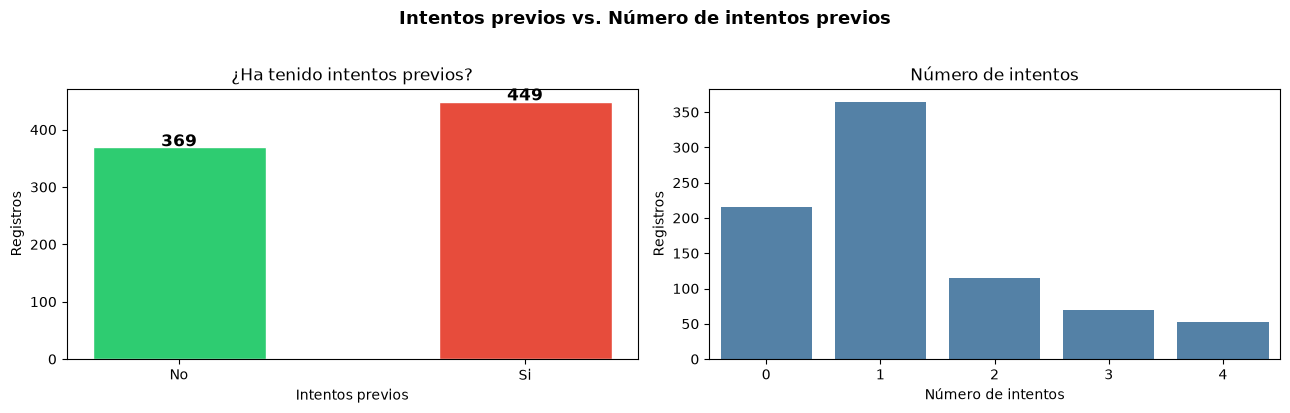

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Izquierda: ¿Ha tenido intentos previos? (SI/NO) ──────────
vc_prev = df["intentos_previos"].value_counts().sort_index()
labels_prev = {0: "No", 1: "Si"}
bars = axes[0].bar(
    [labels_prev[v] for v in vc_prev.index], vc_prev.values,
    color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5
)
for bar, val in zip(bars, vc_prev.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("¿Ha tenido intentos previos?")
axes[0].set_xlabel("Intentos previos")
axes[0].set_ylabel("Registros")

# ── Derecha: Número de intentos ───────────────────────────────
sns.countplot(x=df["numero_de_intentos"], color="steelblue", ax=axes[1])
axes[1].set_title("Número de intentos")
axes[1].set_xlabel("Número de intentos")
axes[1].set_ylabel("Registros")

plt.suptitle("Intentos previos vs. Número de intentos previos", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


#### Exportar dataset limpio

In [36]:
df.to_csv('data/data_clean.csv', index=False, encoding='utf-8')